# NOTEBOOK 1 — example-01-BPI-2019.ipynb

In [88]:
# Cell 1 — Setup & Load

import os, shutil, warnings
import pm4py
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

OCEL_PATH  = r"d:\SGH\Thesis\thesis-trang\data\BPIC19_sample.jsonocel"
OUTPUT_DIR = r"d:\SGH\Thesis\thesis-trang\main\figs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("File exists:", os.path.exists(OCEL_PATH))

ocel         = pm4py.read_ocel(OCEL_PATH)
events_df    = ocel.events
objects_df   = ocel.objects
obj_type_col = ocel.object_type_column

print("Total events :", len(events_df))
print("Total objects:", len(objects_df))
print("\nObject type counts:")
print(objects_df[obj_type_col].value_counts())


File exists: True
Total events : 53198
Total objects: 71559

Object type counts:
ocel:type
POItem      43903
PO          25825
Vendor       1354
Resource      477
Name: count, dtype: int64


In [89]:
#cell 1b: explore events:

print("=" * 50)
print("EVENTS DataFrame")
print("=" * 50)
print(f"Shape: {events_df.shape}")
print(f"\nColumns:\n{events_df.columns.tolist()}")
print(f"\nSample rows:")
display(events_df.head(5))
print(f"\nNull values:")
print(events_df.isnull().sum())


EVENTS DataFrame
Shape: (53198, 22)

Columns:
['ocel:eid', 'ocel:timestamp', 'ocel:activity', 'ID', 'cCompany', 'cDocType', 'cGR', 'cGRbasedInvVerif', 'cID', 'cItem', 'cItemCat', 'cItemType', 'cPOID', 'cPurDocCat', 'cSpendAreaText', 'cSpendClassText', 'cSubSPendAreaText', 'cVendor', 'cVendorName', 'eCumNetWorth', 'idx', 'resource']

Sample rows:


,ocel:eid,ocel:timestamp,ocel:activity,ID,cCompany,cDocType,cGR,cGRbasedInvVerif,cID,cItem,...,cPOID,cPurDocCat,cSpendAreaText,cSpendClassText,cSubSPendAreaText,cVendor,cVendorName,eCumNetWorth,idx,resource
0,1900003,1948-01-26 22:59:00+00:00,Vendor creates invoice,65781719105536,companyID_0000,Standard PO,True,False,4507004931_00020,20.0,...,4.507005e+09,Purchase order,Sales,NPR,Products for Resale,vendorID_0670,vendor_0645,68.0,0.0,NONE
1,1900033,2001-04-24 22:59:00+00:00,Vendor creates invoice,240050017140737,companyID_0000,Standard PO,True,False,4507017103_00030,30.0,...,4.507017e+09,Purchase order,Packaging,PR,Metal Containers & Lids < 30L,vendorID_0167,vendor_0165,7498.0,30.0,NONE
2,1900063,2008-06-19 22:59:00+00:00,Vendor creates invoice,536376990760960,companyID_0000,Standard PO,True,True,4507037128_00130,130.0,...,4.507037e+09,Purchase order,Sales,NPR,Products for Resale,vendorID_0236,vendor_0231,174.0,60.0,NONE
3,1900093,2016-02-29 22:59:00+00:00,Vendor creates invoice,52458730553347,companyID_0000,Framework order,True,True,4507003966_00010,10.0,...,4.507004e+09,Purchase order,CAPEX & SOCS,NPR,MRO (components),vendorID_0886,vendor_0846,5322.0,90.0,NONE
4,1900123,2017-04-18 22:59:00+00:00,Vendor creates invoice,295347721076736,companyID_0000,Standard PO,True,False,4507020620_00040,40.0,...,4.507021e+09,Purchase order,Sales,NPR,Products for Resale,vendorID_0270,vendor_0263,4572.0,120.0,NONE



Null values:
ocel:eid               0
ocel:timestamp         0
ocel:activity          0
ID                     0
cCompany               0
cDocType               0
cGR                    0
cGRbasedInvVerif       0
cID                    0
cItem                  0
cItemCat               0
cItemType              0
cPOID                  0
cPurDocCat             0
cSpendAreaText       564
cSpendClassText      564
cSubSPendAreaText    564
cVendor                0
cVendorName            0
eCumNetWorth           0
idx                    0
resource               0
dtype: int64


In [90]:
#cell 1c: explore objects
print("=" * 50)
print("OBJECTS DataFrame")
print("=" * 50)
print(f"Shape: {objects_df.shape}")
print(f"\nColumns:\n{objects_df.columns.tolist()}")
print(f"\nSample rows:")
display(objects_df.head(5))
print(f"\nObject type distribution:")
display(objects_df[obj_type_col].value_counts().to_frame("count"))

OBJECTS DataFrame
Shape: (71559, 2)

Columns:
['ocel:oid', 'ocel:type']

Sample rows:


,ocel:oid,ocel:type
0,0,PO
1,1,PO
2,5,PO
3,7,PO
4,11,PO



Object type distribution:


,count
ocel:type,
POItem,43903
PO,25825
Vendor,1354
Resource,477


In [91]:
#cell 1d: time range & activity distribution:

print("=" * 50)
print("TIME RANGE")
print("=" * 50)

# Auto-detect timestamp column
print("All columns in events_df:", events_df.columns.tolist())

ts_col = None
for candidate in ["time:timestamp", "ocel:timestamp", "timestamp", "time"]:
    if candidate in events_df.columns:
        ts_col = candidate
        break

if ts_col is None:
    # pick first column that looks like a date
    for col in events_df.columns:
        try:
            sample = pd.to_datetime(events_df[col].dropna().iloc[0])
            ts_col = col
            break
        except:
            continue

print(f"Timestamp column found: '{ts_col}'")

ts = pd.to_datetime(events_df[ts_col], utc=True, errors="coerce")
print(f"Start : {ts.min()}")
print(f"End   : {ts.max()}")
print(f"Span  : {(ts.max() - ts.min()).days} days")

print("\n" + "=" * 50)
print("ACTIVITY DISTRIBUTION (all events)")
print("=" * 50)

# Auto-detect activity column
act_col = None
for candidate in ["concept:name", "ocel:activity", "activity"]:
    if candidate in events_df.columns:
        act_col = candidate
        break

print(f"Activity column found: '{act_col}'")
act_dist = events_df[act_col].value_counts()
print(f"Distinct activities: {len(act_dist)}")
display(act_dist.to_frame("count").head(20))


TIME RANGE
All columns in events_df: ['ocel:eid', 'ocel:timestamp', 'ocel:activity', 'ID', 'cCompany', 'cDocType', 'cGR', 'cGRbasedInvVerif', 'cID', 'cItem', 'cItemCat', 'cItemType', 'cPOID', 'cPurDocCat', 'cSpendAreaText', 'cSpendClassText', 'cSubSPendAreaText', 'cVendor', 'cVendorName', 'eCumNetWorth', 'idx', 'resource']
Timestamp column found: 'ocel:timestamp'
Start : 1948-01-26 22:59:00+00:00
End   : 2019-01-18 10:29:00+00:00
Span  : 25924 days

ACTIVITY DISTRIBUTION (all events)
Activity column found: 'ocel:activity'
Distinct activities: 37


,count
ocel:activity,
Record Goods Receipt,10312
Create Purchase Order Item,8504
Record Invoice Receipt,7701
Vendor creates invoice,7367
Clear Invoice,6515
Record Service Entry Sheet,5499
Remove Payment Block,1912
Create Purchase Requisition Item,1555
Receive Order Confirmation,1046


In [92]:
#Cell 1e — Business attributes
print("=" * 50)
print("BUSINESS ATTRIBUTES")
print("=" * 50)

skip_cols = ["ocel:eid", ts_col, act_col, "ocel:activity", "ocel:type"]
business_cols = [c for c in events_df.columns if c not in skip_cols]
print(f"Business columns found: {business_cols}\n")

for col in business_cols[:8]:
    unique_vals = events_df[col].dropna().unique()
    print(f"[{col}]")
    print(f"  Unique values : {len(unique_vals)}")
    print(f"  Examples      : {list(unique_vals[:5])}")
    print()

BUSINESS ATTRIBUTES
Business columns found: ['ID', 'cCompany', 'cDocType', 'cGR', 'cGRbasedInvVerif', 'cID', 'cItem', 'cItemCat', 'cItemType', 'cPOID', 'cPurDocCat', 'cSpendAreaText', 'cSpendClassText', 'cSubSPendAreaText', 'cVendor', 'cVendorName', 'eCumNetWorth', 'idx', 'resource']

[ID]
  Unique values : 53198
  Examples      : ['65781719105536', '240050017140737', '536376990760960', '52458730553347', '295347721076736']

[cCompany]
  Unique values : 2
  Examples      : ['companyID_0000', 'companyID_0003']

[cDocType]
  Unique values : 3
  Examples      : ['Standard PO', 'Framework order', 'EC Purchase order']

[cGR]
  Unique values : 2
  Examples      : ['True', 'False']

[cGRbasedInvVerif]
  Unique values : 2
  Examples      : ['False', 'True']

[cID]
  Unique values : 43903
  Examples      : ['4507004931_00020', '4507017103_00030', '4507037128_00130', '4507003966_00010', '4507020620_00040']

[cItem]
  Unique values : 240
  Examples      : [20.0, 30.0, 130.0, 10.0, 40.0]

[cItemCat

In [93]:
# Cell 1f — Object types & relationships

print("=" * 50)
print("OBJECTS DETAIL")
print("=" * 50)
display(objects_df.head(10))

print("\nObject type counts:")
display(objects_df[obj_type_col].value_counts().to_frame("count"))

# Relations between events and objects
if hasattr(ocel, "relations"):
    rel_df = ocel.relations
    print(f"\nEvent-Object relations: {len(rel_df)}")
    print(f"Columns: {rel_df.columns.tolist()}")
    display(rel_df.head(10))
    
    objs_per_event = rel_df.groupby("ocel:eid").size()
    print(f"\nObjects per event — Mean: {objs_per_event.mean():.2f}  Max: {objs_per_event.max()}")
else:
    print("\nNo relations attribute found in this OCEL.")


OBJECTS DETAIL


,ocel:oid,ocel:type
0,0,PO
1,1,PO
2,5,PO
3,7,PO
4,11,PO
5,20,PO
6,21,PO
7,32,PO
8,33,PO
9,34,PO



Object type counts:


,count
ocel:type,
POItem,43903
PO,25825
Vendor,1354
Resource,477



Event-Object relations: 199488
Columns: ['ocel:eid', 'ocel:activity', 'ocel:timestamp', 'ocel:oid', 'ocel:type', 'ocel:qualifier']


,ocel:eid,ocel:activity,ocel:timestamp,ocel:oid,ocel:type,ocel:qualifier
0,1900003,Vendor creates invoice,1948-01-26 22:59:00+00:00,1925149,Vendor,None
1,1900003,Vendor creates invoice,1948-01-26 22:59:00+00:00,37436,PO,None
2,1900003,Vendor creates invoice,1948-01-26 22:59:00+00:00,131113,POItem,None
3,1900033,Vendor creates invoice,2001-04-24 22:59:00+00:00,1924719,Vendor,None
4,1900033,Vendor creates invoice,2001-04-24 22:59:00+00:00,81186,PO,None
5,1900033,Vendor creates invoice,2001-04-24 22:59:00+00:00,244979,POItem,None
6,1900063,Vendor creates invoice,2008-06-19 22:59:00+00:00,1924969,Vendor,None
7,1900063,Vendor creates invoice,2008-06-19 22:59:00+00:00,7542,PO,None
8,1900063,Vendor creates invoice,2008-06-19 22:59:00+00:00,243047,POItem,None
9,1900093,Vendor creates invoice,2016-02-29 22:59:00+00:00,81410,PO,None



Objects per event — Mean: 3.75  Max: 4


In [94]:
# Cell 1g — Full dataset summary
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

summary = pd.DataFrame({
    "Metric": [
        "Total events",
        "Total objects",
        "Distinct activities",
        "Object types",
        "Business attribute columns",
        "Date range start",
        "Date range end",
        "Time span (days)"
    ],
    "Value": [
        len(events_df),
        len(objects_df),
        events_df[act_col].nunique(),
        objects_df[obj_type_col].nunique(),
        len(business_cols),
        str(ts.min().date()),
        str(ts.max().date()),
        (ts.max() - ts.min()).days
    ]
})

display(summary)



DATASET SUMMARY


,Metric,Value
0,Total events,53198
1,Total objects,71559
2,Distinct activities,37
3,Object types,4
4,Business attribute columns,19
5,Date range start,1948-01-26
6,Date range end,2019-01-18
7,Time span (days),25924


In [95]:
# Cell 2 — Flatten to classic log

most_common_type = objects_df[obj_type_col].value_counts().index[0]
print("Selected object type:", most_common_type)

classic_log = pm4py.ocel_flattening(ocel, most_common_type)
print("Cases after flattening:", len(classic_log))

df_full = pm4py.convert_to_dataframe(classic_log)
print("Events in classic log:", len(df_full))
print("Columns:", df_full.columns.tolist()[:10])


Selected object type: POItem
Cases after flattening: 53198
Events in classic log: 53198
Columns: ['ocel:eid', 'time:timestamp', 'concept:name', 'ID', 'cCompany', 'cDocType', 'cGR', 'cGRbasedInvVerif', 'cID', 'cItem']


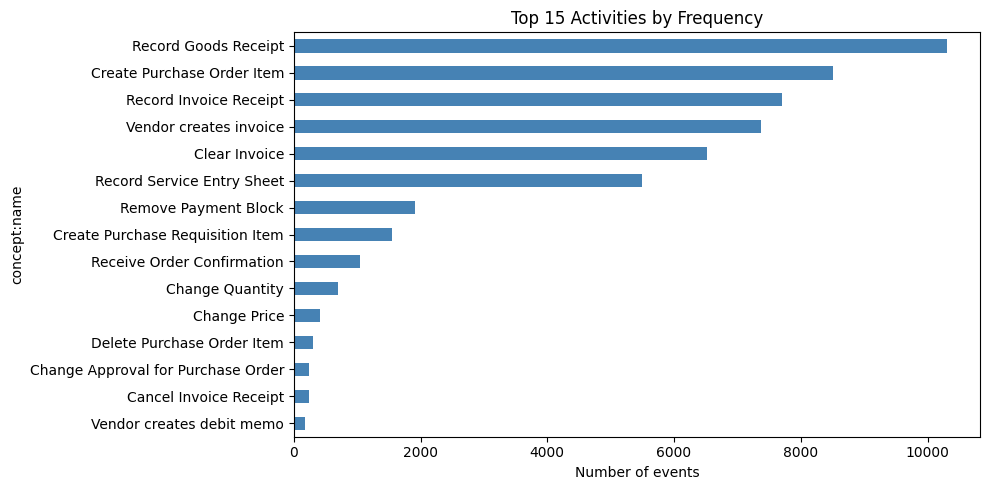

Saved: fig_01_activity_freq.png


In [96]:
# Cell 3 — Fig 01: Top 15 Activities

act_counts = df_full["concept:name"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
act_counts.sort_values().plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("Top 15 Activities by Frequency")
ax.set_xlabel("Number of events")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig_01_activity_freq.png"), dpi=150)
plt.show()
print("Saved: fig_01_activity_freq.png")

In [97]:
#Cell 4 — Basic statistics
print("=== Basic Log Statistics ===")
print(f"Total cases    : {len(classic_log)}")
print(f"Total events   : {len(df_full)}")
print(f"Activities     : {df_full['concept:name'].nunique()}")

print("\nTop 10 activities:")
print(df_full["concept:name"].value_counts().head(10).to_string())


=== Basic Log Statistics ===
Total cases    : 53198
Total events   : 53198
Activities     : 37

Top 10 activities:
concept:name
Record Goods Receipt                10312
Create Purchase Order Item           8504
Record Invoice Receipt               7701
Vendor creates invoice               7367
Clear Invoice                        6515
Record Service Entry Sheet           5499
Remove Payment Block                 1912
Create Purchase Requisition Item     1555
Receive Order Confirmation           1046
Change Quantity                       705


In [98]:
#Cell 5 — Process Discovery (train/test split)

TRAIN_SIZE = 2000
TEST_SIZE  = 2000

train_log = classic_log[:TRAIN_SIZE]
test_log  = classic_log[TRAIN_SIZE : TRAIN_SIZE + TEST_SIZE]

print(f"Train cases : {len(train_log)}")
print(f"Test cases  : {len(test_log)}")

print("\nRunning Inductive Miner on train set...")
net, im, fm = pm4py.discover_petri_net_inductive(train_log)

print(f"\nPetri net:")
print(f"  Places     : {len(net.places)}")
print(f"  Transitions: {len(net.transitions)}")
print(f"  Arcs       : {len(net.arcs)}")


Train cases : 2000
Test cases  : 2000

Running Inductive Miner on train set...

Petri net:
  Places     : 24
  Transitions: 54
  Arcs       : 114


Saved: fig_02_petri_net.png


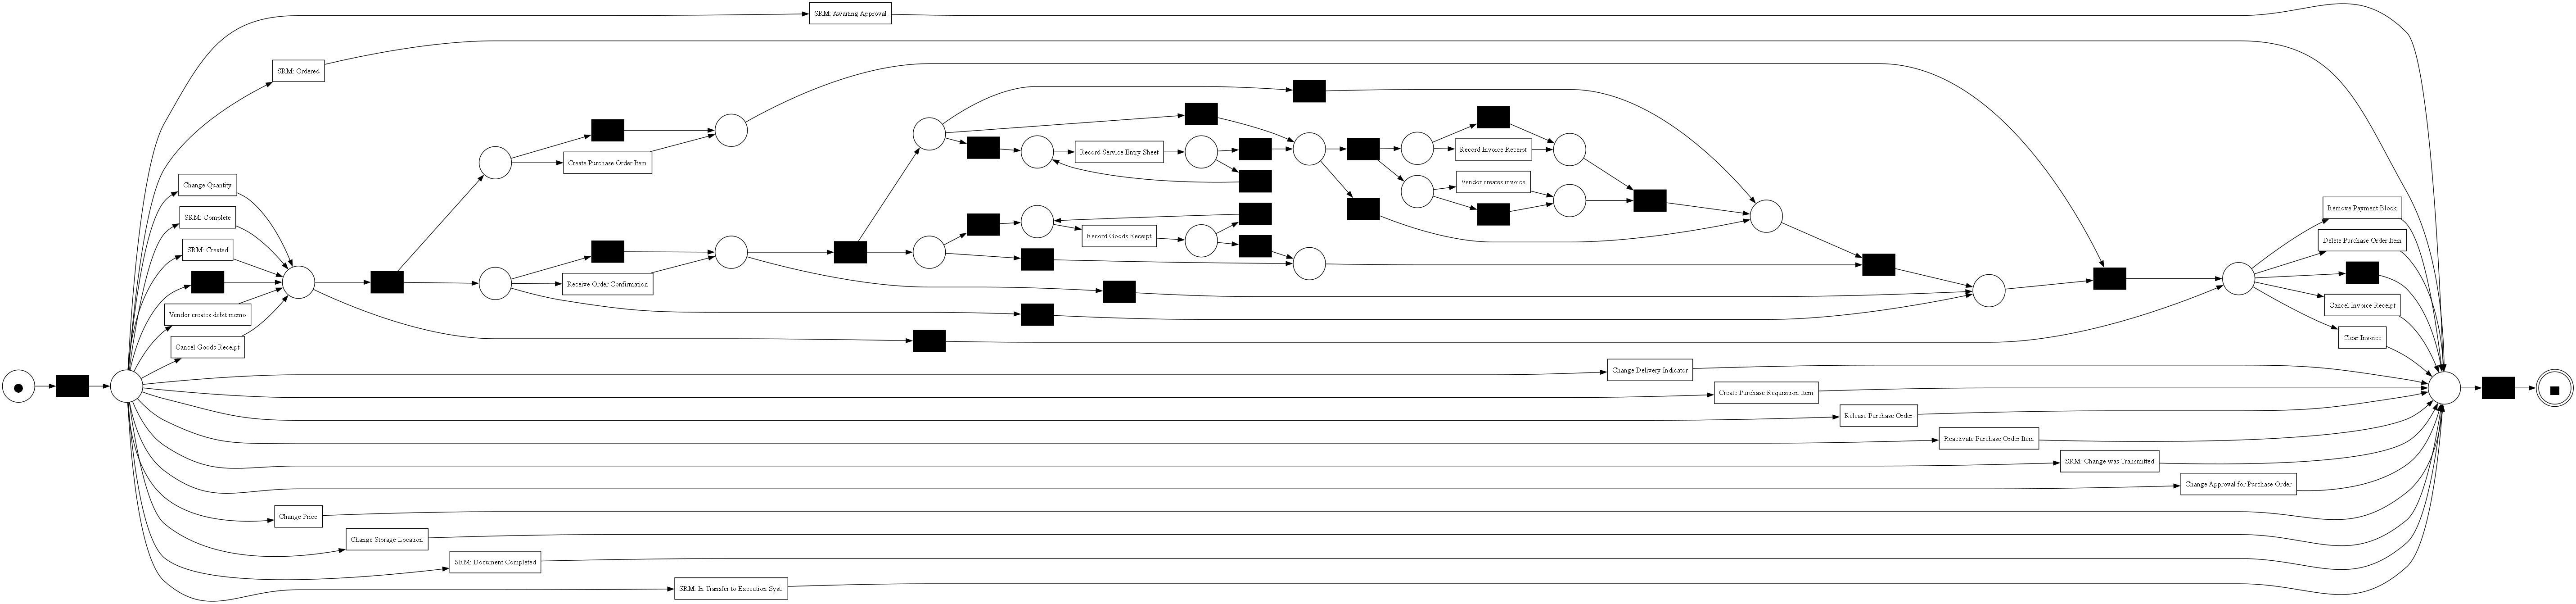

In [99]:
#cell 6: save & view model

if shutil.which("dot"):
    out = os.path.join(OUTPUT_DIR, "fig_02_petri_net.png")
    pm4py.save_vis_petri_net(net, im, fm, out)
    print("Saved: fig_02_petri_net.png")
    pm4py.view_petri_net(net, im, fm)
else:
    print("Graphviz not found — saving DFG instead")
    dfg, start_acts, end_acts = pm4py.discover_dfg(sample_log)
    out = os.path.join(OUTPUT_DIR, "fig_02_dfg.png")
    pm4py.save_vis_dfg(dfg, start_acts, end_acts, out)
    print("Saved: fig_02_dfg.png")
    pm4py.view_dfg(dfg, start_acts, end_acts)


In [100]:
# Cell 7 — Conformance Checking (token-based replay on TEST set)

# Token-based replay on unseen test set
fitness_test = pm4py.fitness_token_based_replay(test_log, net, im, fm)

print("=== Conformance Checking (Token-Based Replay) ===")
print(f"Evaluated on : {len(test_log)} UNSEEN cases (not used for discovery)")
print(f"Log fitness          : {fitness_test['log_fitness']:.4f}")
print(f"Average trace fitness: {fitness_test['average_trace_fitness']:.4f}")
print(f"Perfectly fitting    : {fitness_test['percentage_of_fitting_traces']:.1f}%")

# Interpretation
fit_val = fitness_test['log_fitness']
if fit_val >= 0.95:
    msg = "Excellent — model captures real process behaviour well"
elif fit_val >= 0.80:
    msg = "Good — minor deviations exist"
elif fit_val >= 0.60:
    msg = "Moderate — notable deviations, consider IMf threshold tuning"
else:
    msg = "Poor — model does not represent the log well"

print(f"\nInterpretation: {msg}")


replaying log with TBR, completed traces ::   0%|          | 0/83 [00:00<?, ?it/s]

=== Conformance Checking (Token-Based Replay) ===
Evaluated on : 2000 UNSEEN cases (not used for discovery)
Log fitness          : 0.9997
Average trace fitness: 0.9994
Perfectly fitting    : 99.6%

Interpretation: Excellent — model captures real process behaviour well


# Notebook 2 — example-02-advanced.ipynb

In [101]:
#cell1: set up & load

import os, warnings
import pm4py
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

warnings.filterwarnings("ignore")

OCEL_PATH  = r"d:\SGH\Thesis\thesis-trang\data\BPIC19_sample.jsonocel"
OUTPUT_DIR = r"d:\SGH\Thesis\thesis-trang\main\figs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

ocel         = pm4py.read_ocel(OCEL_PATH)
obj_type_col = ocel.object_type_column
most_common_type = ocel.objects[obj_type_col].value_counts().index[0]

classic_log = pm4py.ocel_flattening(ocel, most_common_type)
df_full     = pm4py.convert_to_dataframe(classic_log)

print("Object type :", most_common_type)
print("Cases       :", len(classic_log))
print("Events      :", len(df_full))

Object type : POItem
Cases       : 53198
Events      : 53198


In [102]:
#Cell 2 — Variant Analysis
variants = pm4py.get_variants(classic_log)
print("Total distinct variants:", len(variants))

sorted_variants = sorted(variants.items(), key=lambda x: x[1], reverse=True)

total_cases  = len(classic_log)
top10_cases  = sum(v[1] for v in sorted_variants[:10])
top20_cases  = sum(v[1] for v in sorted_variants[:20])

print(f"Top-10 variants cover : {top10_cases/total_cases:.1%} of all cases")
print(f"Top-20 variants cover : {top20_cases/total_cases:.1%} of all cases")

Total distinct variants: 826
Top-10 variants cover : 70.5% of all cases
Top-20 variants cover : 75.8% of all cases


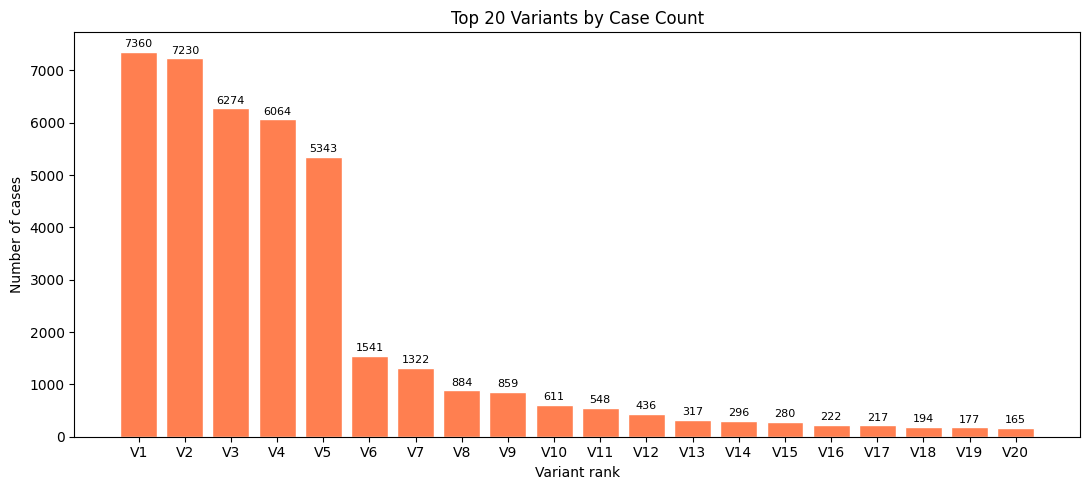

Saved: fig_03_variant_freq.png


In [103]:
#cell3: Fig 03: Variant Frequency Chart

top20  = sorted_variants[:20]
labels = [f"V{i+1}" for i in range(len(top20))]
counts = [v[1] for v in top20]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, counts, color="coral", edgecolor="white")
ax.set_title("Top 20 Variants by Case Count")
ax.set_xlabel("Variant rank")
ax.set_ylabel("Number of cases")
ax.bar_label(bars, fmt="%d", fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig_03_variant_freq.png"), dpi=150)
plt.show()
print("Saved: fig_03_variant_freq.png")

In [104]:
# Cell 4 — Throughput Time (with anomaly filtering)

df_full["time:timestamp"] = pd.to_datetime(
    df_full["time:timestamp"], utc=True, errors="coerce"
)

valid = df_full.groupby("case:concept:name").filter(lambda x: len(x) >= 2)

tt = (
    valid.groupby("case:concept:name")["time:timestamp"].max()
  - valid.groupby("case:concept:name")["time:timestamp"].min()
)
throughput_days_raw = tt.dt.total_seconds() / 86400

# Filter: remove < 15 min (0.01 day) and top 1% outliers
p99 = throughput_days_raw.quantile(0.99)
throughput_days = throughput_days_raw[
    (throughput_days_raw > 0.01) &      # ← đổi từ > 0 thành > 0.01
    (throughput_days_raw <= p99)
]

removed = len(throughput_days_raw) - len(throughput_days)
print(f"Cases with >= 2 events (raw)         : {len(throughput_days_raw)}")
print(f"Cases after anomaly filter           : {len(throughput_days)}")
print(f"Removed (< 15 min or > P99={p99:.0f}d)  : {removed}")
print(f"\nCleaned throughput stats:")
print(throughput_days.describe().round(2))


Cases with >= 2 events (raw)         : 4869
Cases after anomaly filter           : 4003
Removed (< 15 min or > P99=280d)  : 866

Cleaned throughput stats:
count    4003.00
mean       36.77
std        47.60
min         0.01
25%         2.77
50%        17.92
75%        54.92
max       279.76
Name: time:timestamp, dtype: float64


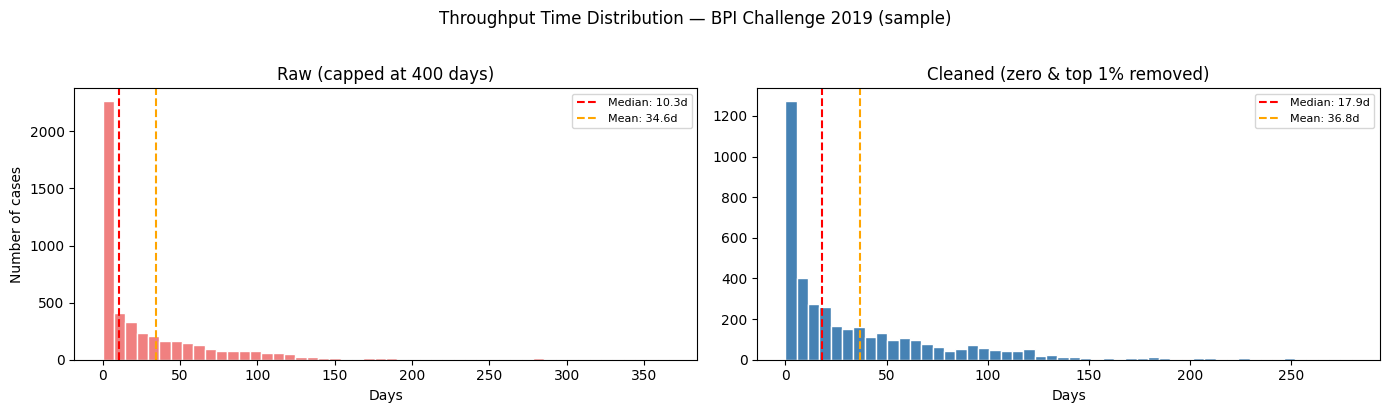

Saved: fig_04_throughput.png


In [105]:
# Cell 5 — Fig 04: Throughput Time Histogram (cleaned)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: raw (with anomalies, capped at 400d)
axes[0].hist(throughput_days_raw[throughput_days_raw <= 400].dropna(),
             bins=50, color="lightcoral", edgecolor="white")
axes[0].axvline(throughput_days_raw.median(), color="red", linestyle="--",
                label=f"Median: {throughput_days_raw.median():.1f}d")
axes[0].axvline(throughput_days_raw.mean(), color="orange", linestyle="--",
                label=f"Mean: {throughput_days_raw.mean():.1f}d")
axes[0].set_title("Raw (capped at 400 days)")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Number of cases")
axes[0].legend(fontsize=8)

# Right: cleaned
axes[1].hist(throughput_days.dropna(),
             bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(throughput_days.median(), color="red", linestyle="--",
                label=f"Median: {throughput_days.median():.1f}d")
axes[1].axvline(throughput_days.mean(), color="orange", linestyle="--",
                label=f"Mean: {throughput_days.mean():.1f}d")
axes[1].set_title("Cleaned (zero & top 1% removed)")
axes[1].set_xlabel("Days")
axes[1].legend(fontsize=8)

plt.suptitle("Throughput Time Distribution — BPI Challenge 2019 (sample)", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig_04_throughput.png"), dpi=150)
plt.show()
print("Saved: fig_04_throughput.png")


In [106]:
#cell 6: Loop/ rework detection:

sample_cases = df_full["case:concept:name"].drop_duplicates().head(3000)
df_small     = df_full[df_full["case:concept:name"].isin(sample_cases)]

repeat_cases       = 0
repeat_act_counter = Counter()

for case_id, g in df_small.groupby("case:concept:name"):
    cnt = Counter(g["concept:name"].tolist())
    if any(v > 1 for v in cnt.values()):
        repeat_cases += 1
        for a, v in cnt.items():
            if v > 1:
                repeat_act_counter[a] += 1

rework_rate = repeat_cases / len(sample_cases)
print(f"Rework rate: {rework_rate:.1%}")
print("\nTop repeated activities:")
for act, count in repeat_act_counter.most_common(10):
    print(f"  {act}: {count} cases")


Rework rate: 4.9%

Top repeated activities:
  Record Service Entry Sheet: 112 cases
  Record Goods Receipt: 58 cases
  Record Invoice Receipt: 18 cases
  Vendor creates invoice: 11 cases
  Clear Invoice: 6 cases
  Change Quantity: 2 cases


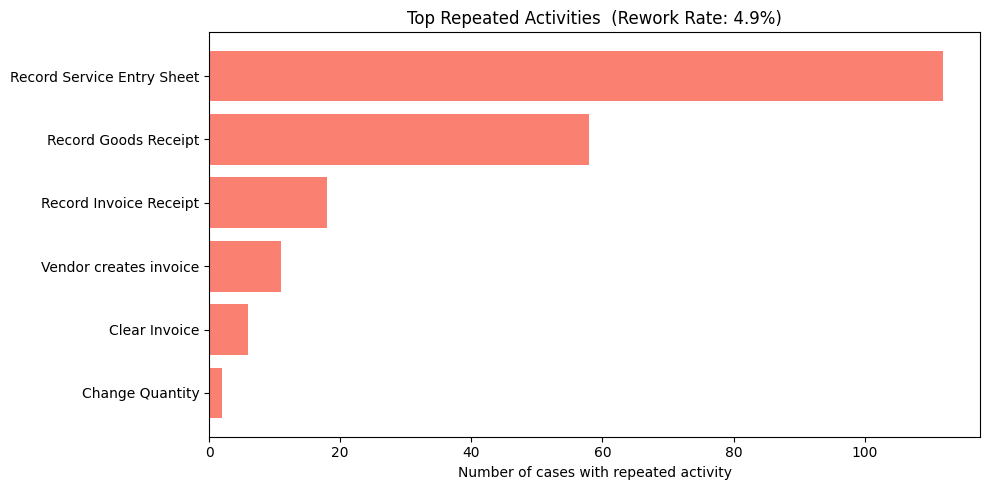

Saved: fig_05_rework.png


In [107]:
# cell7: Fig 05: rework Chart 

if repeat_act_counter:
    top_rework      = repeat_act_counter.most_common(10)
    acts_r, cnts_r  = zip(*top_rework)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(list(acts_r)[::-1], list(cnts_r)[::-1], color="salmon")
    ax.set_title(f"Top Repeated Activities  (Rework Rate: {rework_rate:.1%})")
    ax.set_xlabel("Number of cases with repeated activity")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "fig_05_rework.png"), dpi=150)
    plt.show()
    print("Saved: fig_05_rework.png")
else:
    print("No rework detected in sample.")


In [108]:
# Cell 8 — KPI Summary Table (updated with cleaned stats)

summary = pd.DataFrame({
    "Metric": [
        "Total cases",
        "Total distinct variants",
        "Top-10 variant coverage",
        "Top-20 variant coverage",
        "Cases with >= 2 events (raw)",
        "Cases after anomaly filter",
        "Mean throughput (days)",
        "Median throughput (days)",
        "P95 throughput (days)",
        "Min throughput (days)",
        "Max throughput (days)",
        "Rework rate (sample 3000)"
    ],
    "Value": [
        len(classic_log),
        len(variants),
        f"{top10_cases/total_cases:.1%}",
        f"{top20_cases/total_cases:.1%}",
        len(throughput_days_raw),
        len(throughput_days),
        round(throughput_days.mean(), 2),
        round(throughput_days.median(), 2),
        round(throughput_days.quantile(0.95), 2),
        round(throughput_days.min(), 2),
        round(throughput_days.max(), 2),
        f"{rework_rate:.1%}"
    ]
})

display(summary)


,Metric,Value
0,Total cases,53198
1,Total distinct variants,826
2,Top-10 variant coverage,70.5%
3,Top-20 variant coverage,75.8%
4,Cases with >= 2 events (raw),4869
5,Cases after anomaly filter,4003
6,Mean throughput (days),36.77
7,Median throughput (days),17.92
8,P95 throughput (days),126.47
9,Min throughput (days),0.01


                    count    mean     std  min    25%     50%     75%      max
doc_type                                                                      
EC Purchase order   109.0   88.54  110.40  0.0   3.79   34.20  137.04   365.89
Framework order     184.0  164.71  109.52  0.0  57.73  177.92  258.17   366.00
Standard PO        4576.0   28.09   98.98  0.0   0.14    8.36   40.61  6208.44


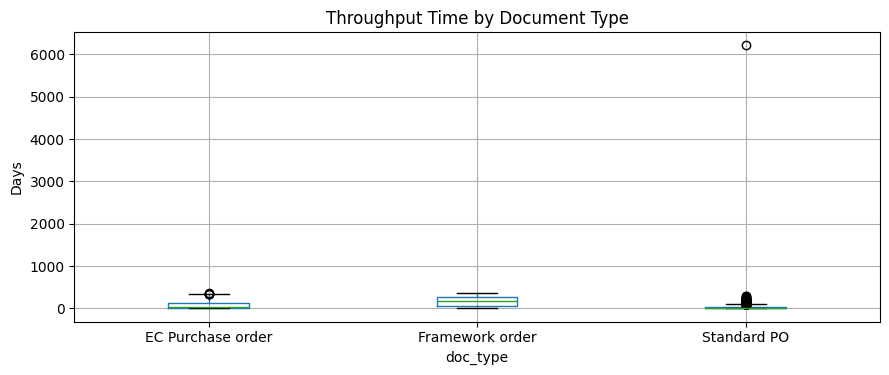

In [109]:
#cell 9: breakdown by document type: 

# Breakdown by cDocType
doc_type_tt = (
    df_full[df_full["case:concept:name"].isin(valid["case:concept:name"])]
    .groupby("case:concept:name")
    .agg(
        doc_type=("cDocType", "first"),
        tt_days=("time:timestamp", lambda x: (x.max() - x.min()).total_seconds() / 86400)
    )
    .reset_index()
)

print(doc_type_tt.groupby("doc_type")["tt_days"].describe().round(2))

fig, ax = plt.subplots(figsize=(9, 4))
doc_type_tt.boxplot(column="tt_days", by="doc_type", ax=ax)
ax.set_title("Throughput Time by Document Type")
ax.set_ylabel("Days")
plt.suptitle("")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig_06_throughput_by_doctype.png"), dpi=150)
plt.show()
